# 🥗 Healthy Diet & Calorie Intake — Full Data Science Workflow

**Dataset:** 6,000 people × 15 features covering demographics, diet habits, macronutrient intake, and health outcomes.

**Workflow at a glance:**

| # | Section | What we do |
|---|---------|-----------|
| 1 | Setup | Load libraries & data |
| 2 | EDA — Data Composition | What the data is made of |
| 3 | EDA — Data Distribution | How values spread out |
| 4 | EDA — Data Relationships | How features connect to each other |
| 5 | EDA — Data Comparison | How groups differ |
| 6 | Feature Selection | Choose the most useful columns |
| 7 | Model Training & Evaluation | Predict Health Status |
| 8 | Interpretation | What the model tells us |

---


## 1 ⚙️ Setup — Libraries & Data Loading

We start by importing everything we need and loading the CSV.  
A quick sanity check (`shape`, `dtypes`, `head`) confirms the data loaded correctly.

In [1]:
# ── Standard data libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine-learning libraries ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.inspection import permutation_importance

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
PALETTE = sns.color_palette('Set2')
plt.rcParams['figure.dpi'] = 120

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


In [2]:
# ── Load the dataset ─────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/aliyasaly1231/healthy-diet-and-calorie-intake/healthy_diet_calorie_intake.csv')

print(f"📦 Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Column names  :\n  {', '.join(df.columns.tolist())}")
print(f"\n🔍 First 5 rows:")
df.head()

📦 Dataset shape : 6,000 rows × 15 columns

📋 Column names  :
  Person_ID, Age, Gender, Height_cm, Weight_kg, BMI, Activity_Level, Daily_Calorie_Requirement, Daily_Calorie_Consumed, Protein_Intake_g, Carbohydrate_Intake_g, Fat_Intake_g, Water_Intake_Liters, Diet_Type, Health_Status

🔍 First 5 rows:


,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


In [3]:
# ── Data types & missing values in one glance ────────────────────────────────
info_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notnull().sum(),
    'missing' : df.isnull().sum(),
    'unique'  : df.nunique()
})
info_df


,dtype,non_null,missing,unique
Person_ID,object,6000,0,6000
Age,int64,6000,0,63
Gender,object,6000,0,3
Height_cm,float64,6000,0,460
Weight_kg,float64,6000,0,633
BMI,float64,6000,0,255
Activity_Level,object,6000,0,5
Daily_Calorie_Requirement,int64,6000,0,1855
Daily_Calorie_Consumed,int64,6000,0,2218
Protein_Intake_g,float64,6000,0,2098


---
## 2 🧩 EDA Pillar 1 — Data Composition

> **Question:** *What is this dataset made of?*

Data composition tells us the **structure** of our data — types, categories, class balance, and completeness.  
It answers: *"What do we have before we look at any numbers?"*


In [4]:
# ── Numerical vs categorical column split ────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.drop('Person_ID', errors='ignore').tolist()
cat_cols = df.select_dtypes(include='object').columns.drop('Person_ID', errors='ignore').tolist()

print(f"🔢 Numerical columns  ({len(num_cols)}) : {num_cols}")
print(f"🔤 Categorical columns ({len(cat_cols)}) : {cat_cols}")


🔢 Numerical columns  (10) : ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']
🔤 Categorical columns (4) : ['Gender', 'Activity_Level', 'Diet_Type', 'Health_Status']


In [5]:
# ── Statistical summary of numerical columns ─────────────────────────────────
df[num_cols].describe().round(2)


,Age,Height_cm,Weight_kg,BMI,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters
count,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00
mean,48.82,168.59,74.07,26.09,2286.22,2490.52,123.77,288.04,93.70,2.73
std,18.14,9.16,12.42,4.16,469.54,602.28,62.00,123.91,43.95,0.68
min,18.00,145.00,40.00,12.90,1223.00,1000.00,17.40,-23.60,23.20,1.50
25%,33.00,161.70,65.50,23.30,1941.00,2057.00,78.80,229.10,65.90,2.20
50%,48.00,168.20,74.10,26.00,2232.50,2433.00,108.90,297.15,82.30,2.60
75%,65.00,175.20,82.70,28.90,2581.25,2859.00,155.10,366.12,105.10,3.10
max,80.00,198.60,116.60,44.00,4079.00,5158.00,457.50,729.70,341.70,5.00


In [6]:
# ── Categorical columns: unique values & their counts ────────────────────────
for col in cat_cols:
    print(f"\n📌 {col}  ({df[col].nunique()} categories)")
    print(df[col].value_counts().to_string())



📌 Gender  (3 categories)
Gender
Male      2892
Female    2855
Other      253

📌 Activity_Level  (5 categories)
Activity_Level
Lightly Active       1627
Moderately Active    1509
Sedentary            1487
Very Active           970
Athlete               407

📌 Diet_Type  (6 categories)
Diet_Type
Balanced         1536
High Protein     1076
Vegetarian       1055
Mediterranean    1027
Keto              721
Vegan             585

📌 Health_Status  (4 categories)
Health_Status
Overweight     2500
Healthy        2249
Obese          1076
Underweight     175


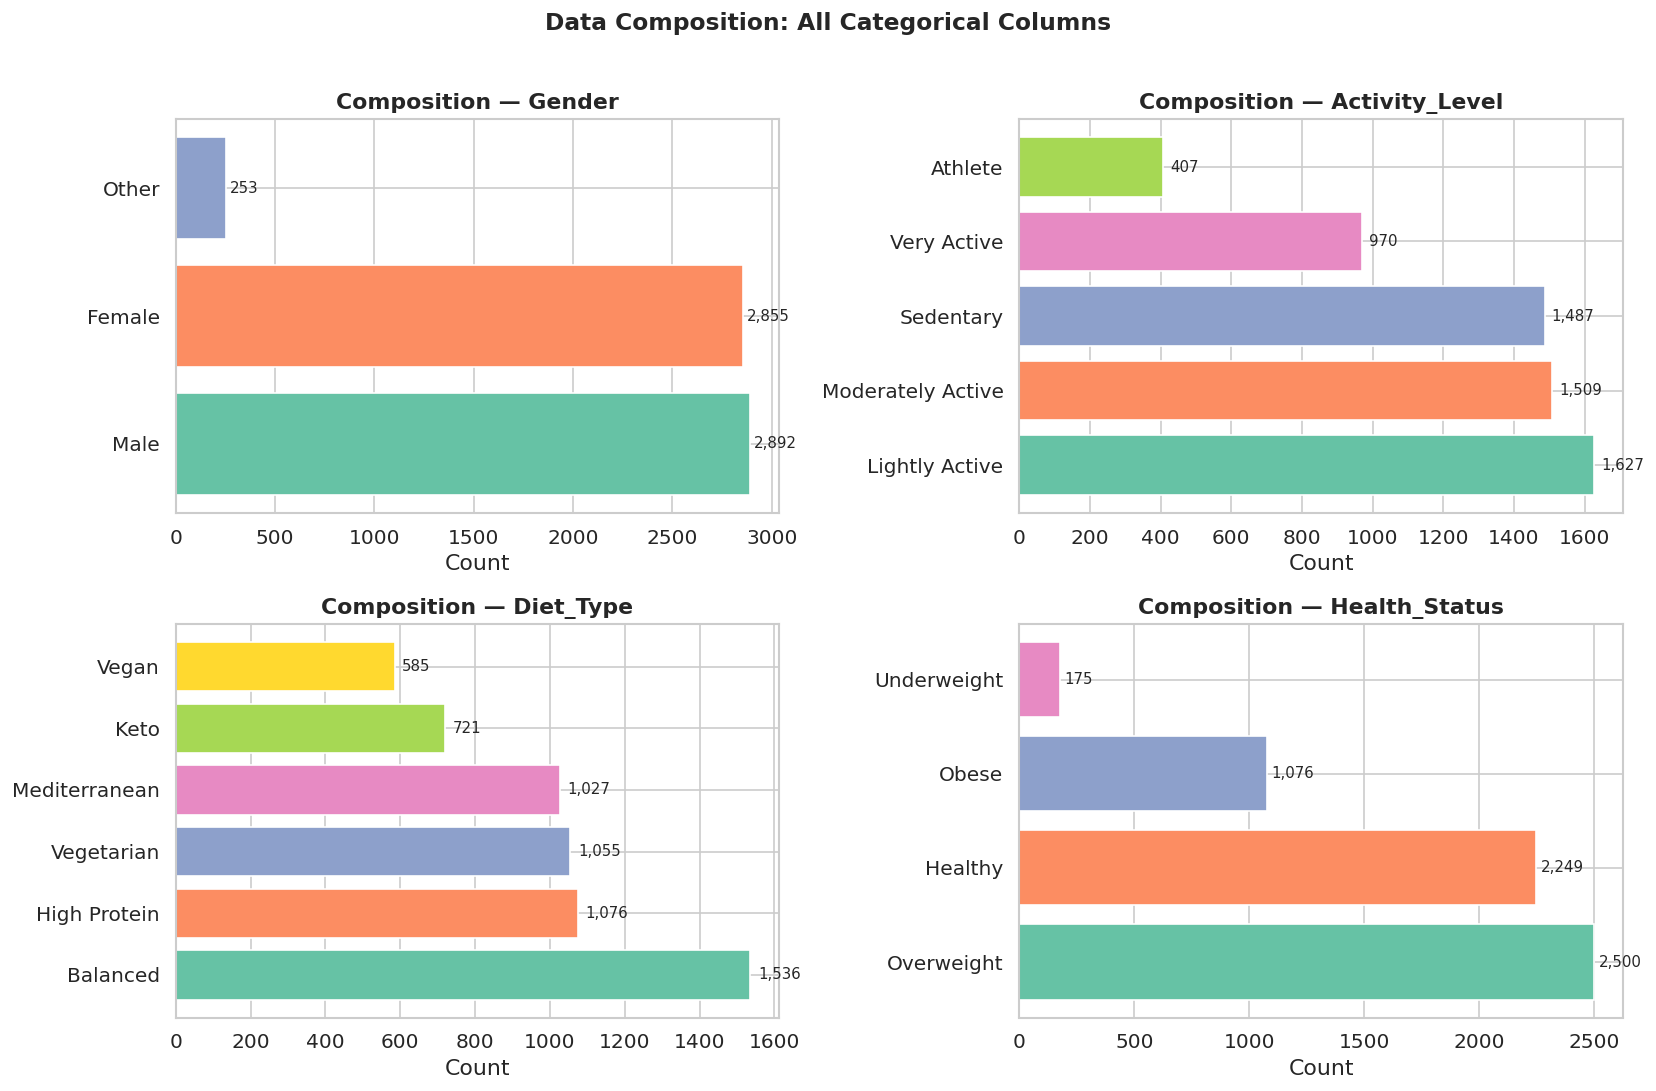

In [7]:
# ── Visual: composition of every categorical column ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values,
                 color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(f'Composition — {col}', fontweight='bold')
    axes[i].set_xlabel('Count')
    for bar, val in zip(axes[i].patches, counts.values):
        axes[i].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=9)

plt.suptitle('Data Composition: All Categorical Columns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


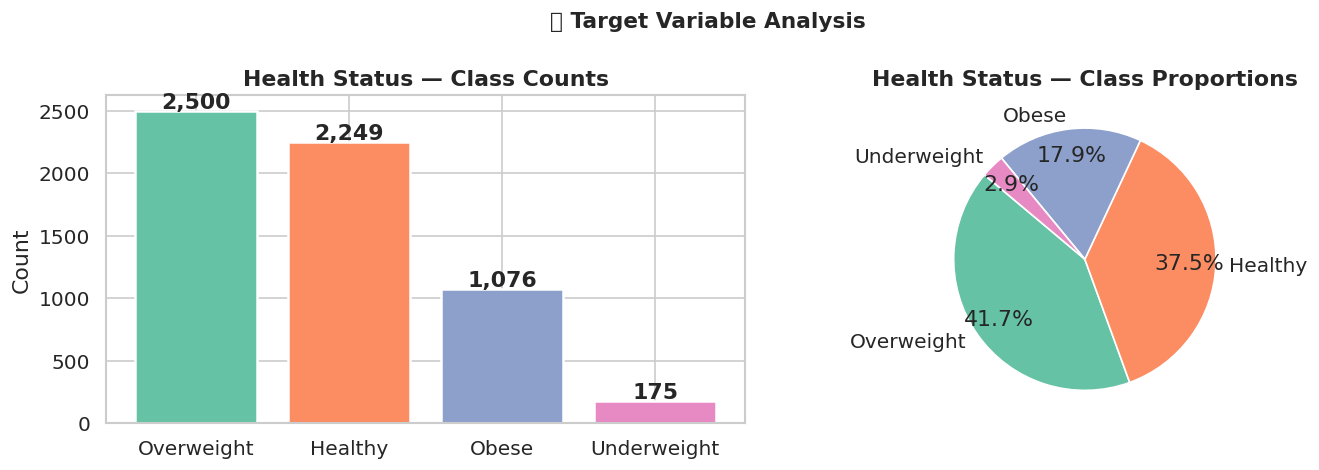


📊 Class balance summary:
  Overweight      2,500  ( 41.7%)  ████████████████████
  Healthy         2,249  ( 37.5%)  ██████████████████
  Obese           1,076  ( 17.9%)  ████████
  Underweight       175  (  2.9%)  █


In [8]:
# ── Class balance check: our target variable (Health_Status) ─────────────────
target_counts = df['Health_Status'].value_counts()
pct           = (target_counts / len(df) * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax1.bar(target_counts.index, target_counts.values,
        color=sns.color_palette('Set2', len(target_counts)), edgecolor='white', linewidth=1.5)
ax1.set_title('Health Status — Class Counts', fontweight='bold')
ax1.set_ylabel('Count')
for bar, val in zip(ax1.patches, target_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,}', ha='center', fontweight='bold')

# Pie chart
ax2.pie(target_counts.values, labels=target_counts.index,
        autopct='%1.1f%%', colors=sns.color_palette('Set2', len(target_counts)),
        startangle=140, pctdistance=0.8)
ax2.set_title('Health Status — Class Proportions', fontweight='bold')

plt.suptitle('🎯 Target Variable Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Class balance summary:")
for label, cnt, p in zip(target_counts.index, target_counts.values, pct.values):
    bar = '█' * int(p / 2)
    print(f"  {label:<15} {cnt:>5,}  ({p:>5}%)  {bar}")


---
## 3 📊 EDA Pillar 2 — Data Distribution

> **Question:** *How are individual values spread out?*

Distribution analysis reveals **shape, spread, skewness, and outliers** for each feature.  
It answers: *"Is this column normally distributed? Are there extreme values?"*


In [9]:
# ── Skewness & kurtosis for all numerical columns ────────────────────────────
skew_df = pd.DataFrame({
    'skewness' : df[num_cols].skew().round(3),
    'kurtosis' : df[num_cols].kurt().round(3)
}).sort_values('skewness', ascending=False)

print("Skewness > |0.5| suggests non-symmetrical distribution")
print("Kurtosis > 3 suggests heavy tails (more outliers)")
print()
skew_df


Skewness > |0.5| suggests non-symmetrical distribution
Kurtosis > 3 suggests heavy tails (more outliers)



,skewness,kurtosis
Fat_Intake_g,1.888,4.219
Protein_Intake_g,1.114,1.126
Water_Intake_Liters,0.762,0.124
Daily_Calorie_Requirement,0.525,-0.041
Daily_Calorie_Consumed,0.507,0.275
BMI,0.155,0.084
Height_cm,0.134,-0.467
Age,0.042,-1.204
Weight_kg,-0.003,-0.257
Carbohydrate_Intake_g,-0.352,0.192


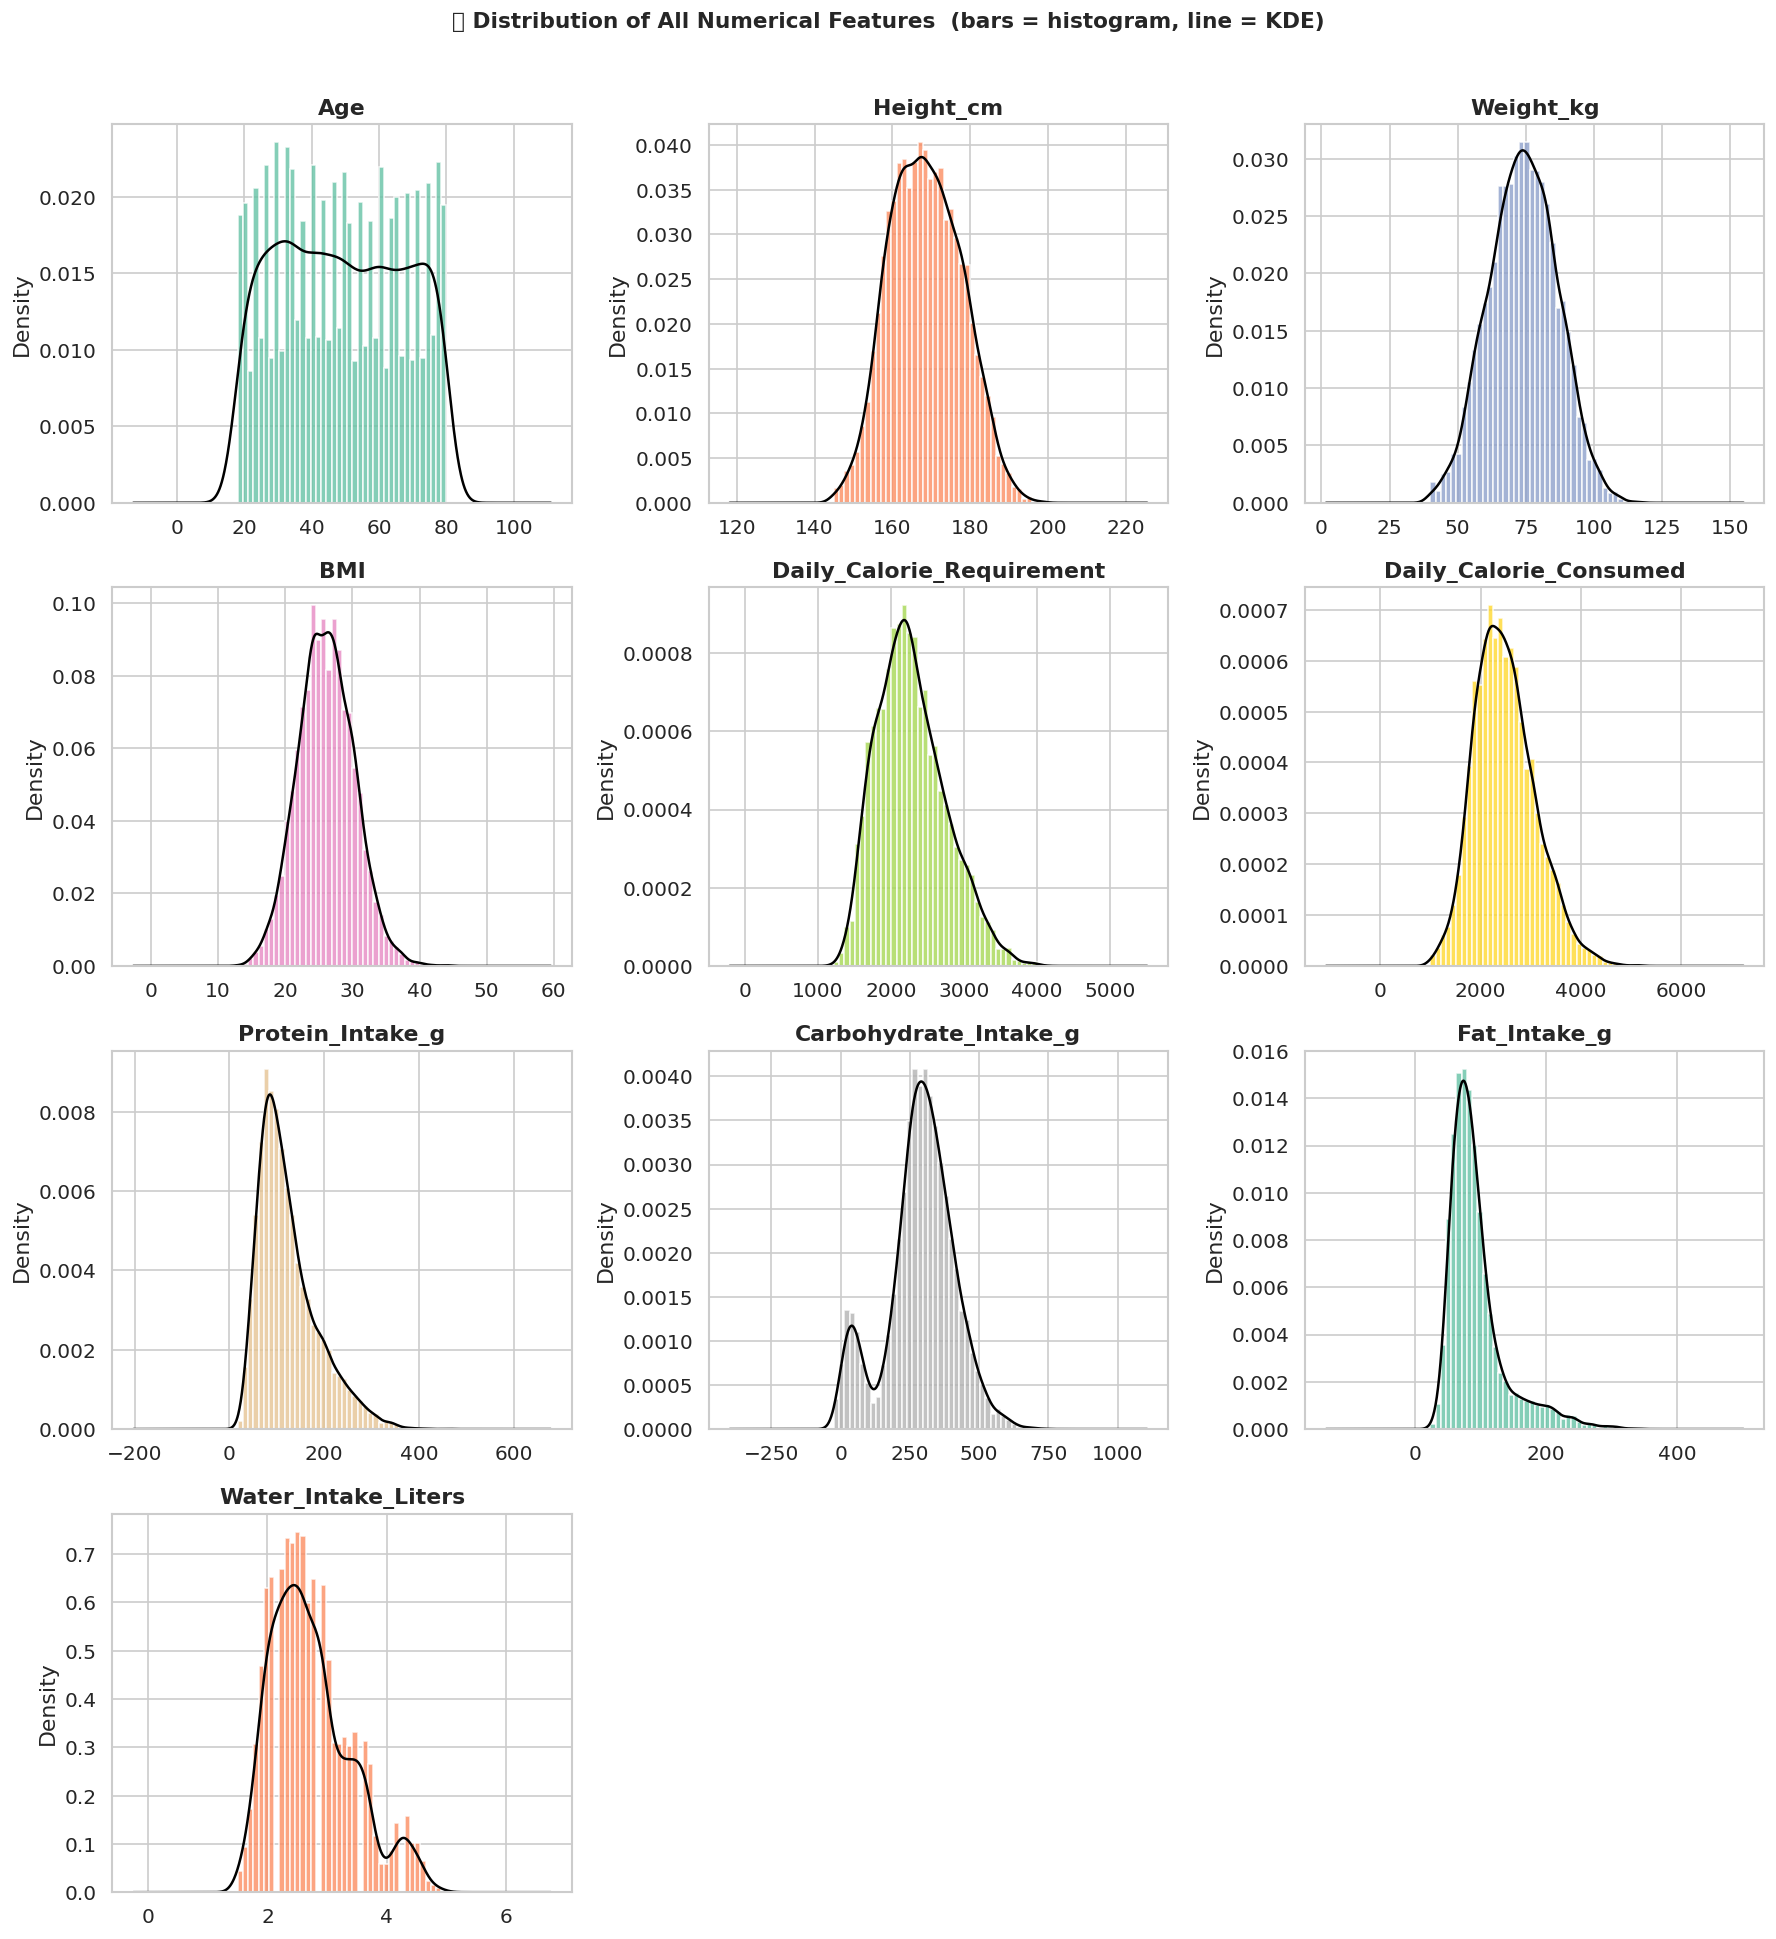

In [10]:
import math
import matplotlib.pyplot as plt

# 1. Dynamically calculate rows needed based on a fixed 3-column layout
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

# 2. Set up the figure with dynamic rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# ── Histograms + KDE for all numerical features ──────────────────────────────
for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=40, color=PALETTE[i % len(PALETTE)],
            edgecolor='white', alpha=0.8, density=True)
    df[col].plot(kind='kde', ax=ax, color='black', linewidth=1.5)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')

# hide spare axes (works perfectly regardless of how many extra slots remain)
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📊 Distribution of All Numerical Features  (bars = histogram, line = KDE)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

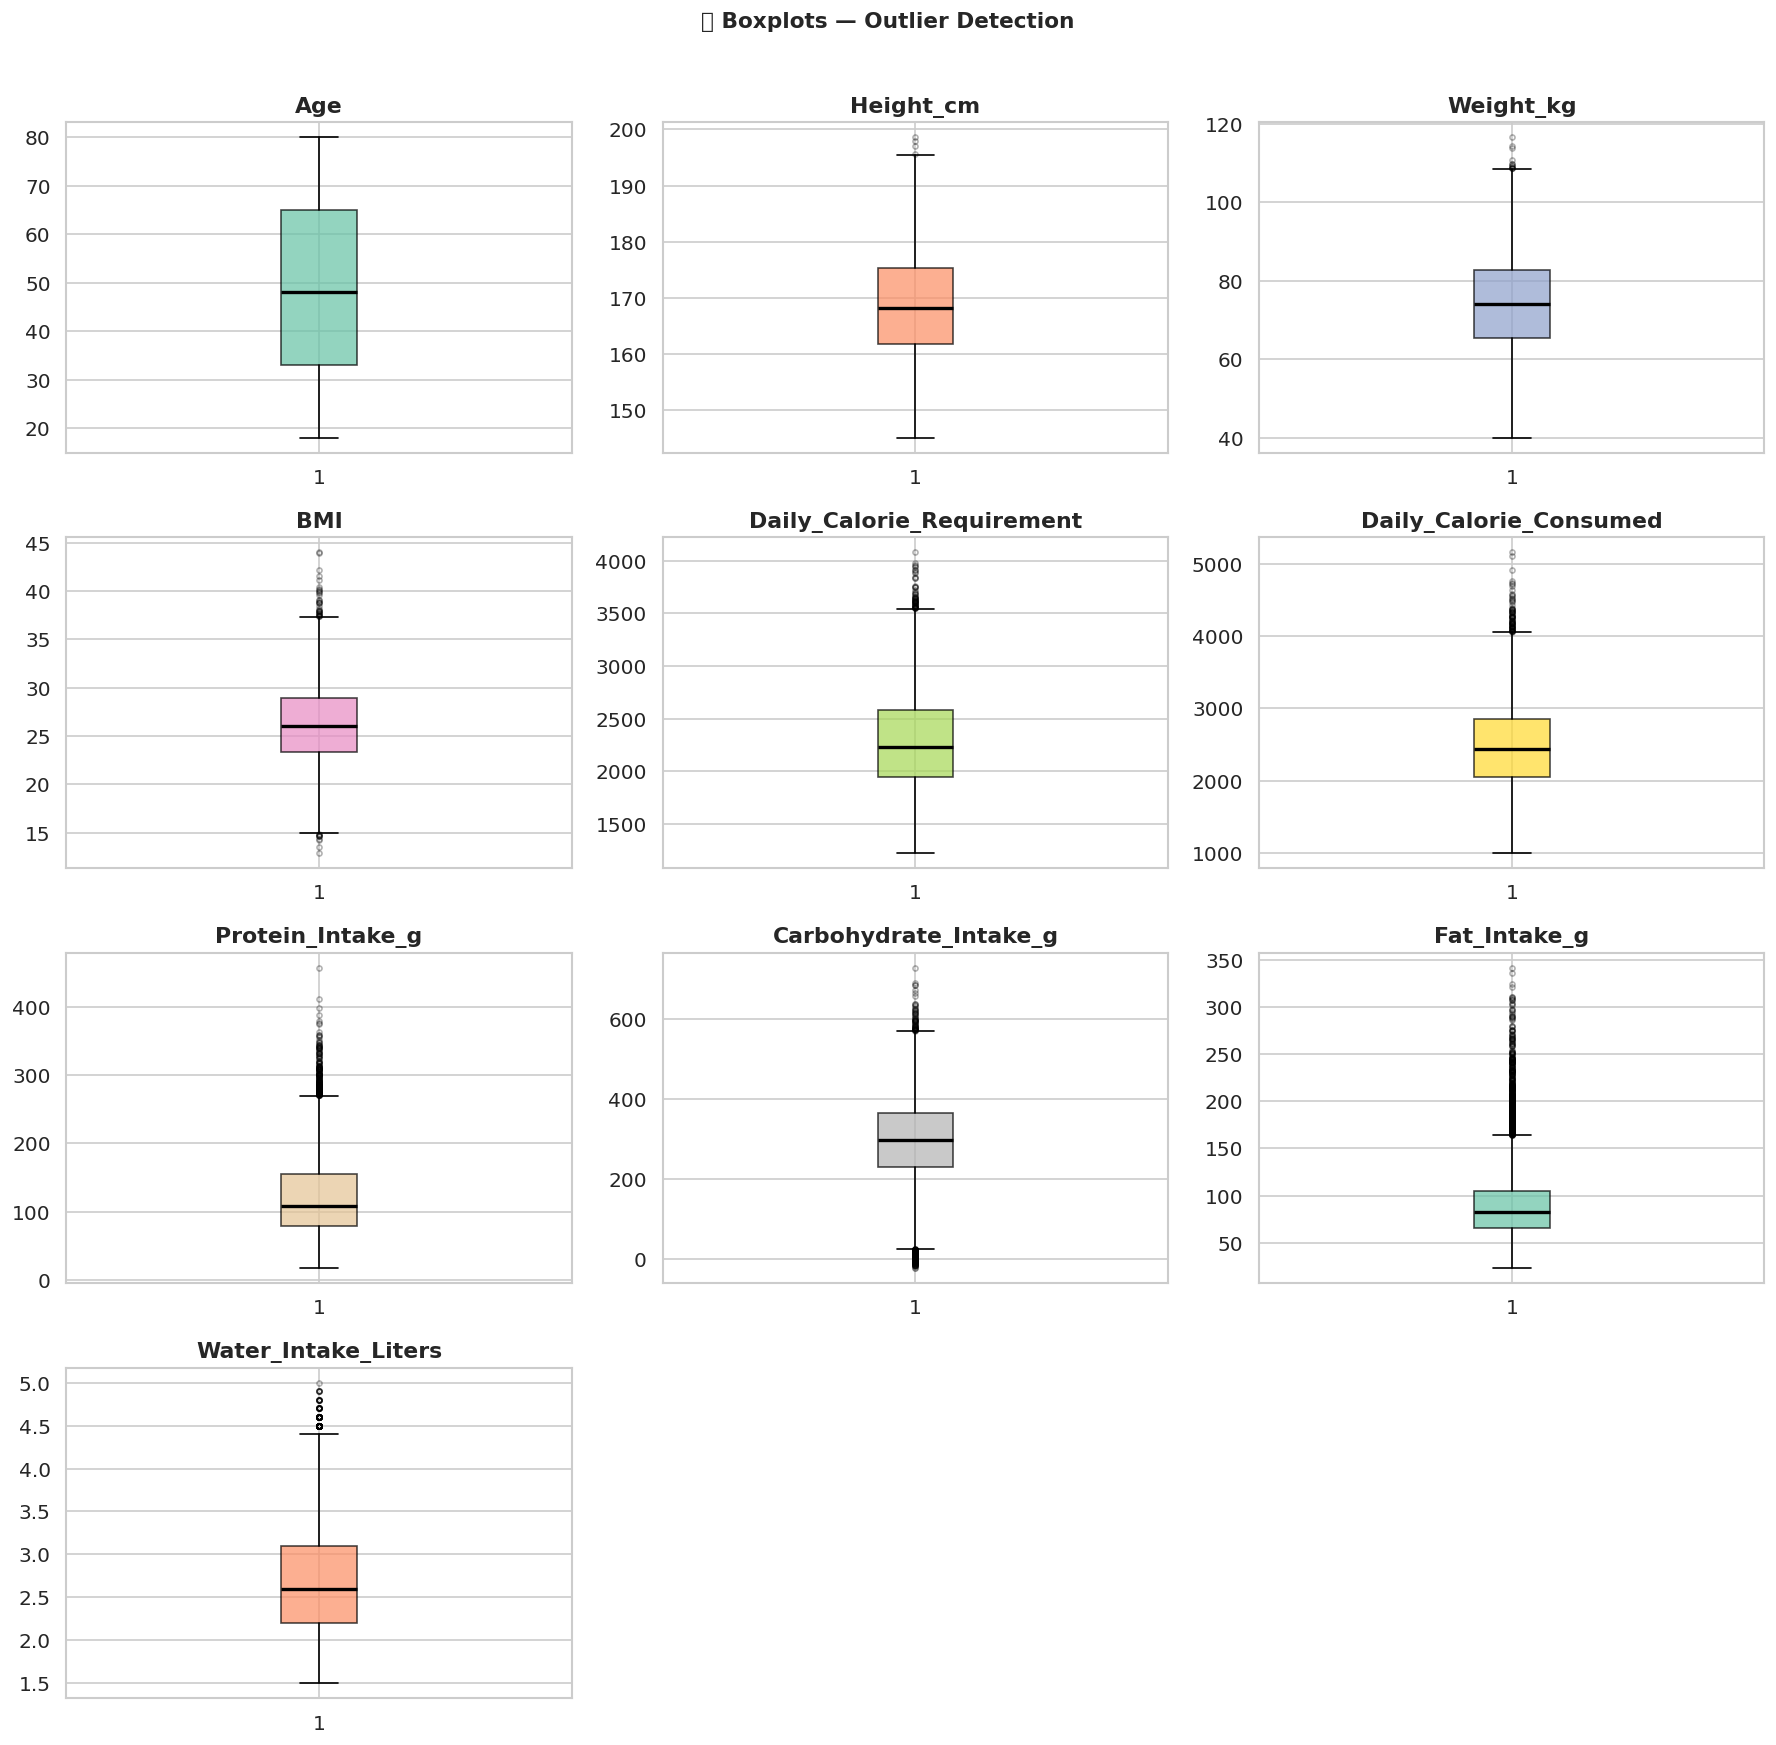

In [11]:
import math
import matplotlib.pyplot as plt

# 1. Dynamically calculate the rows needed for 3 columns
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

# 2. Adjust figsize dynamically based on the row count
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.6 * n_rows))
axes = axes.flatten()

# ── Boxplots: spot outliers at a glance ──────────────────────────────────────
for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.3))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

# 3. Safely hide any leftover empty subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📦 Boxplots — Outlier Detection', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [12]:
# ── IQR-based outlier count per column ───────────────────────────────────────
print("Outlier counts (IQR method):")
print("-" * 40)
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR     = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    pct_out  = len(outliers)/len(df)*100
    flag     = '  ⚠️  worth checking' if pct_out > 5 else ''
    print(f"  {col:<30} {len(outliers):>4} rows  ({pct_out:.1f}%){flag}")


Outlier counts (IQR method):
----------------------------------------
  Age                               0 rows  (0.0%)
  Height_cm                         4 rows  (0.1%)
  Weight_kg                        12 rows  (0.2%)
  BMI                              43 rows  (0.7%)
  Daily_Calorie_Requirement        56 rows  (0.9%)
  Daily_Calorie_Consumed           74 rows  (1.2%)
  Protein_Intake_g                188 rows  (3.1%)
  Carbohydrate_Intake_g           246 rows  (4.1%)
  Fat_Intake_g                    499 rows  (8.3%)  ⚠️  worth checking
  Water_Intake_Liters             114 rows  (1.9%)


---
## 4 🔗 EDA Pillar 3 — Data Relationships

> **Question:** *How do features relate to each other and to the target?*

Relationship analysis uncovers **correlations, patterns, and interactions** between variables.  
It answers: *"Which features move together? Which drive the outcome?"*


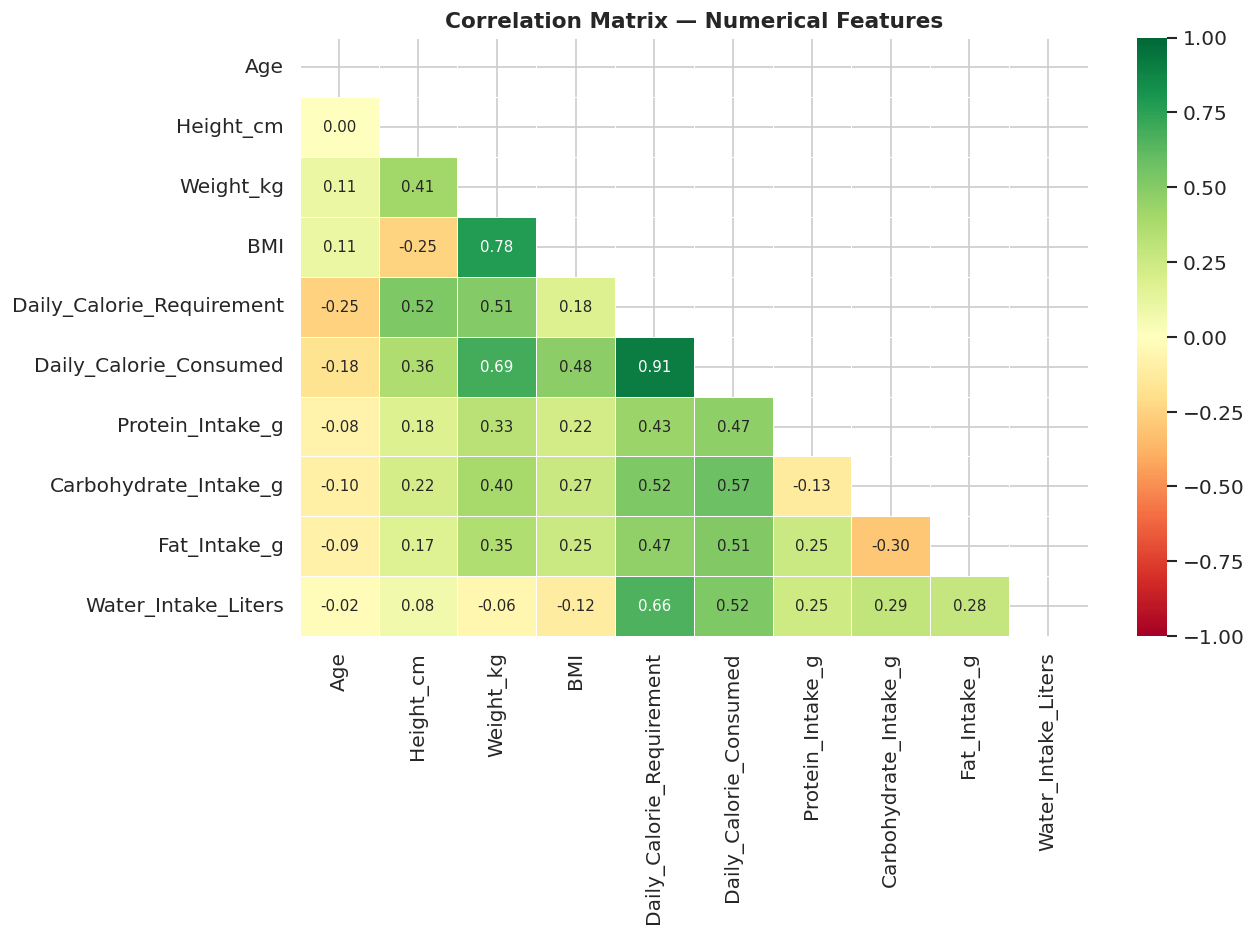

In [13]:
# ── Correlation matrix (Pearson) ─────────────────────────────────────────────
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# ── Top correlations in plain English ────────────────────────────────────────
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
                  .stack()
                  .reset_index()
                  .rename(columns={'level_0':'Feature A','level_1':'Feature B', 0:'Correlation'})
                  .reindex(corr_pairs := None or [],  # placeholder trick
                          )
             ) if False else (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack().reset_index()
        .rename(columns={'level_0':'Feature A','level_1':'Feature B', 0:'r'})
        .assign(abs_r=lambda x: x['r'].abs())
        .sort_values('abs_r', ascending=False)
        .head(10)
)

print("Top 10 strongest correlations:")
for _, row in corr_pairs.iterrows():
    direction = '↑ positive' if row['r'] > 0 else '↓ negative'
    print(f"  {row['Feature A']:<30} ↔  {row['Feature B']:<30}  r = {row['r']:+.3f}  ({direction})")


Top 10 strongest correlations:
  Daily_Calorie_Consumed         ↔  Daily_Calorie_Requirement       r = +0.909  (↑ positive)
  BMI                            ↔  Weight_kg                       r = +0.775  (↑ positive)
  Daily_Calorie_Consumed         ↔  Weight_kg                       r = +0.691  (↑ positive)
  Water_Intake_Liters            ↔  Daily_Calorie_Requirement       r = +0.660  (↑ positive)
  Carbohydrate_Intake_g          ↔  Daily_Calorie_Consumed          r = +0.571  (↑ positive)
  Water_Intake_Liters            ↔  Daily_Calorie_Consumed          r = +0.522  (↑ positive)
  Daily_Calorie_Requirement      ↔  Height_cm                       r = +0.517  (↑ positive)
  Carbohydrate_Intake_g          ↔  Daily_Calorie_Requirement       r = +0.517  (↑ positive)
  Fat_Intake_g                   ↔  Daily_Calorie_Consumed          r = +0.513  (↑ positive)
  Daily_Calorie_Requirement      ↔  Weight_kg                       r = +0.507  (↑ positive)


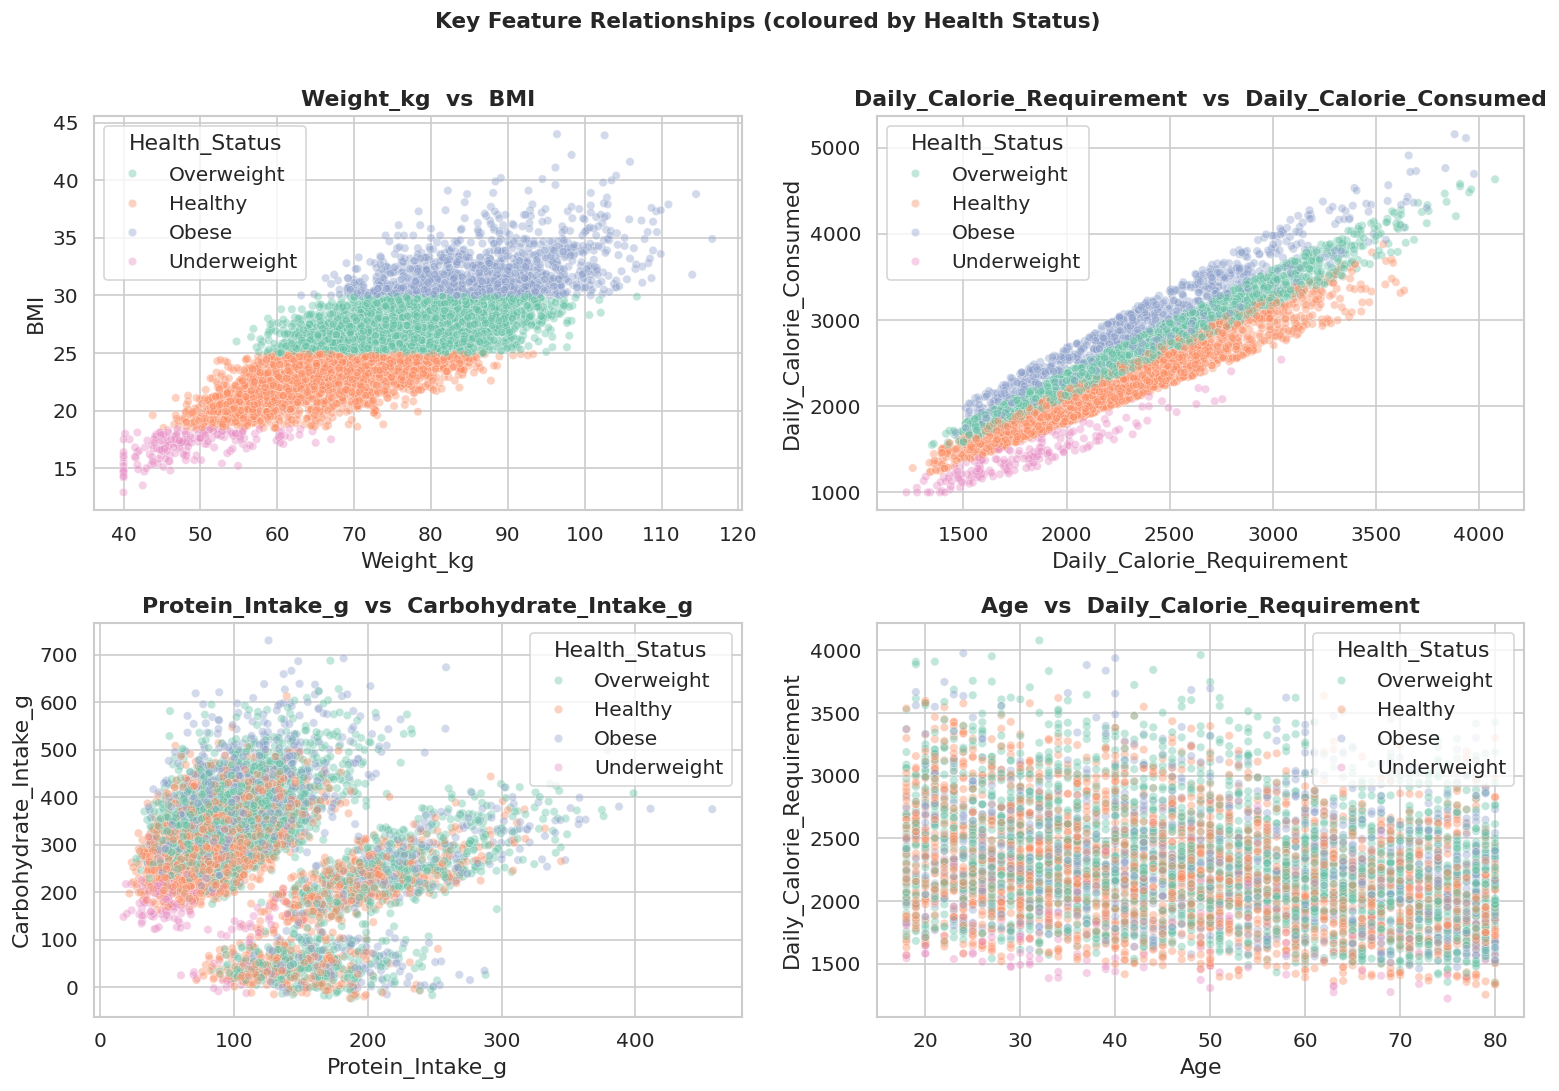

In [15]:
# ── Scatter plots for the strongest pairs ────────────────────────────────────
strong_pairs = [
    ('Weight_kg',              'BMI'),
    ('Daily_Calorie_Requirement','Daily_Calorie_Consumed'),
    ('Protein_Intake_g',       'Carbohydrate_Intake_g'),
    ('Age',                    'Daily_Calorie_Requirement'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
hue_order = df['Health_Status'].value_counts().index.tolist()

for i, (x, y) in enumerate(strong_pairs):
    sns.scatterplot(data=df, x=x, y=y, hue='Health_Status',
                    hue_order=hue_order, alpha=0.4, s=25, ax=axes[i])
    axes[i].set_title(f'{x}  vs  {y}', fontweight='bold')

plt.suptitle('Key Feature Relationships (coloured by Health Status)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


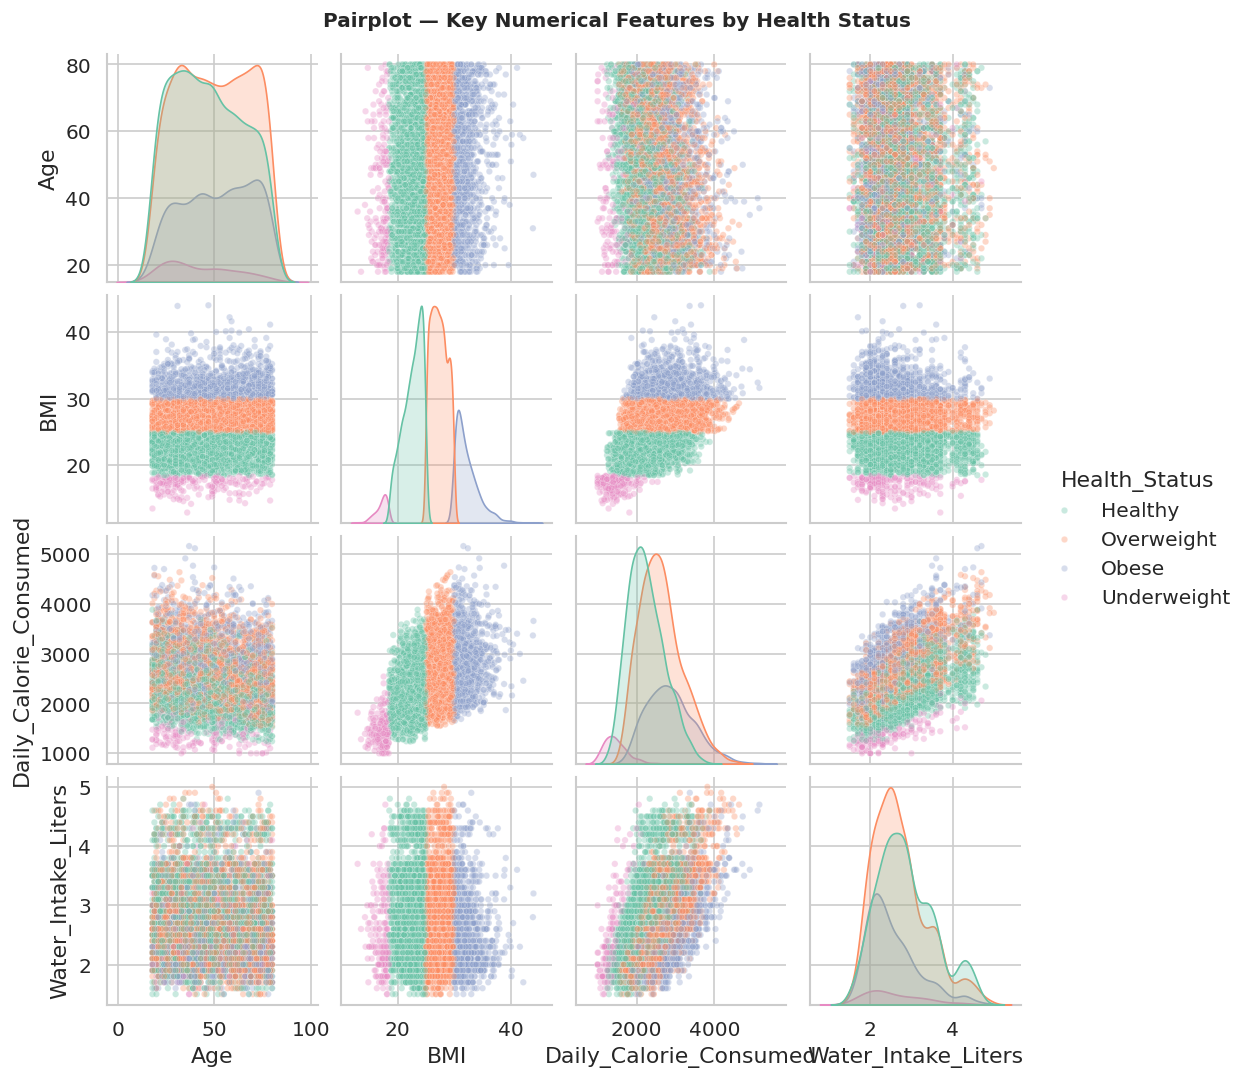

In [16]:
# ── Pairplot for quick multi-feature overview ────────────────────────────────
pair_cols = ['Age', 'BMI', 'Daily_Calorie_Consumed', 'Water_Intake_Liters', 'Health_Status']
pp = sns.pairplot(df[pair_cols], hue='Health_Status', diag_kind='kde',
                  plot_kws={'alpha': 0.35, 's': 15}, height=2.2)
pp.fig.suptitle('Pairplot — Key Numerical Features by Health Status',
                y=1.02, fontsize=12, fontweight='bold')
plt.show()


---
## 5 ⚖️ EDA Pillar 4 — Data Comparison

> **Question:** *How do different groups compare?*

Group comparison highlights **how subgroups differ** across key metrics.  
It answers: *"Do males and females eat differently? Does activity level affect BMI?"*


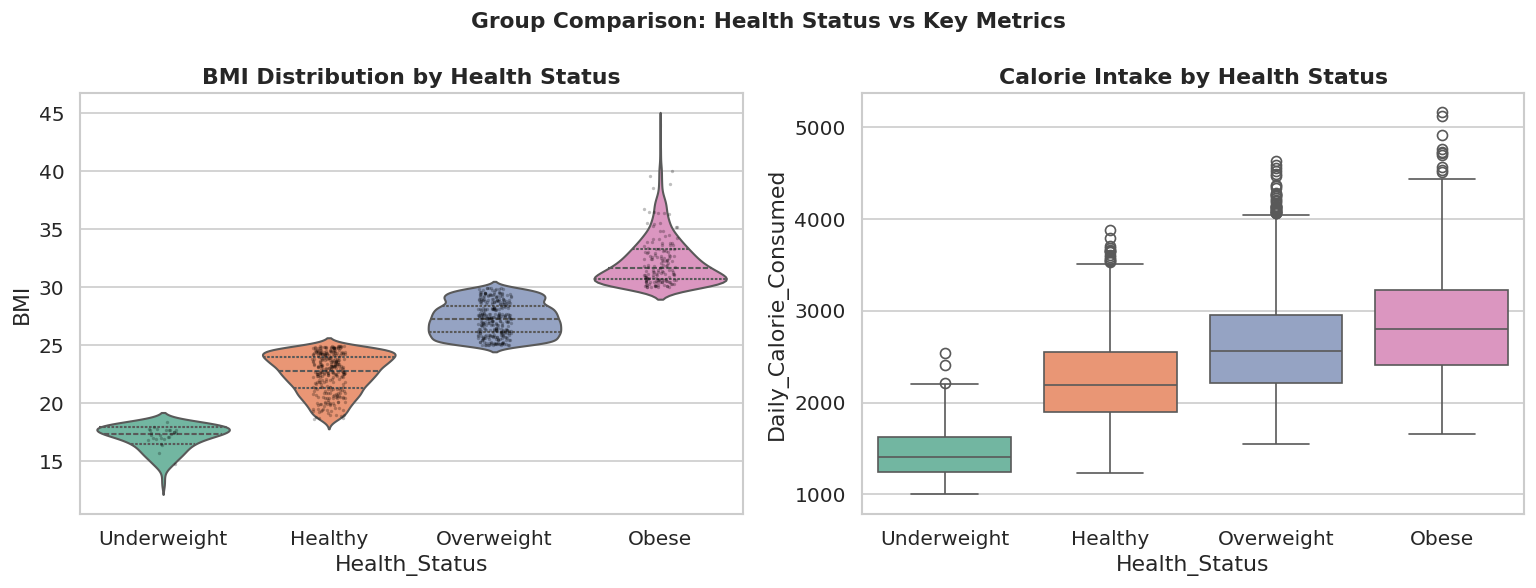

In [17]:
# ── BMI comparison across Health Status groups ───────────────────────────────
order = ['Underweight', 'Healthy', 'Overweight', 'Obese']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin
sns.violinplot(data=df, x='Health_Status', y='BMI', order=order,
               palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('BMI Distribution by Health Status', fontweight='bold')

# Strip (raw data overlay)
sns.stripplot(data=df.sample(800, random_state=42),
              x='Health_Status', y='BMI', order=order,
              color='black', alpha=0.25, size=2, ax=axes[0])

# Box
sns.boxplot(data=df, x='Health_Status', y='Daily_Calorie_Consumed',
            order=order, palette='Set2', ax=axes[1])
axes[1].set_title('Calorie Intake by Health Status', fontweight='bold')

plt.suptitle('Group Comparison: Health Status vs Key Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


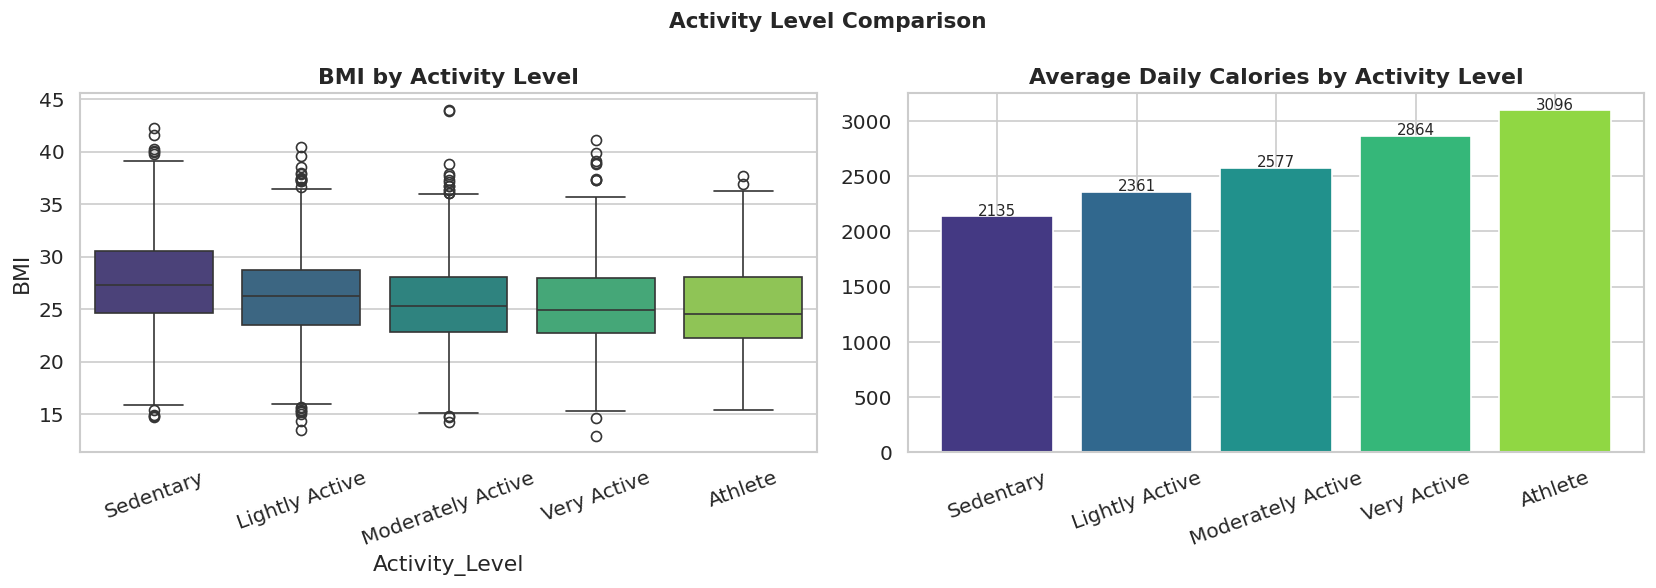

In [18]:
# ── Activity level vs BMI comparison ─────────────────────────────────────────
act_order = ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active', 'Athlete']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Activity_Level', y='BMI', order=act_order,
            palette='viridis', ax=axes[0])
axes[0].set_title('BMI by Activity Level', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Mean calories per activity level
mean_cal = df.groupby('Activity_Level')['Daily_Calorie_Consumed'].mean().reindex(act_order)
axes[1].bar(mean_cal.index, mean_cal.values,
            color=sns.color_palette('viridis', len(act_order)))
axes[1].set_title('Average Daily Calories by Activity Level', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[1].patches, mean_cal.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f}', ha='center', fontsize=9)

plt.suptitle('Activity Level Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


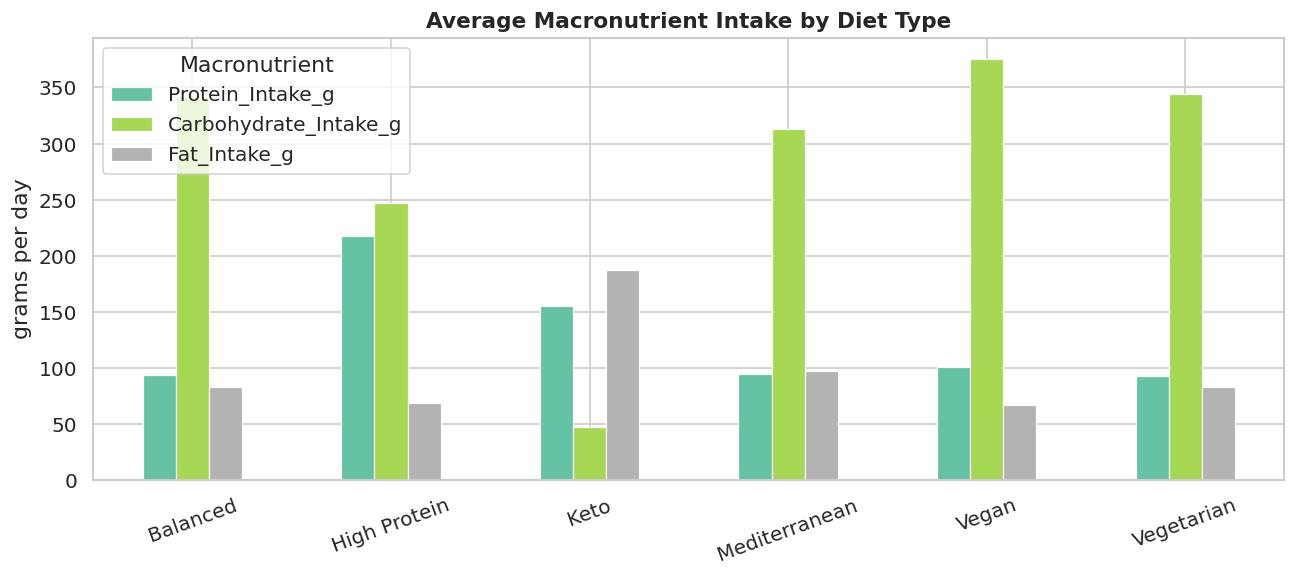


Numerical summary:


,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g
Diet_Type,,,
Balanced,93.2,341.1,82.7
High Protein,217.7,247.0,68.9
Keto,154.7,47.2,186.9
Mediterranean,94.4,313.1,97.0
Vegan,100.9,375.8,66.4
Vegetarian,92.6,344.1,83.1


In [19]:
# ── Diet Type comparison — macronutrient averages ────────────────────────────
macro_cols  = ['Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g']
diet_macros = df.groupby('Diet_Type')[macro_cols].mean().round(1)

diet_macros.plot(kind='bar', figsize=(11, 5), colormap='Set2',
                 edgecolor='white', linewidth=0.7)
plt.title('Average Macronutrient Intake by Diet Type', fontsize=13, fontweight='bold')
plt.ylabel('grams per day')
plt.xlabel('')
plt.xticks(rotation=20)
plt.legend(title='Macronutrient')
plt.tight_layout()
plt.show()

print("\nNumerical summary:")
diet_macros


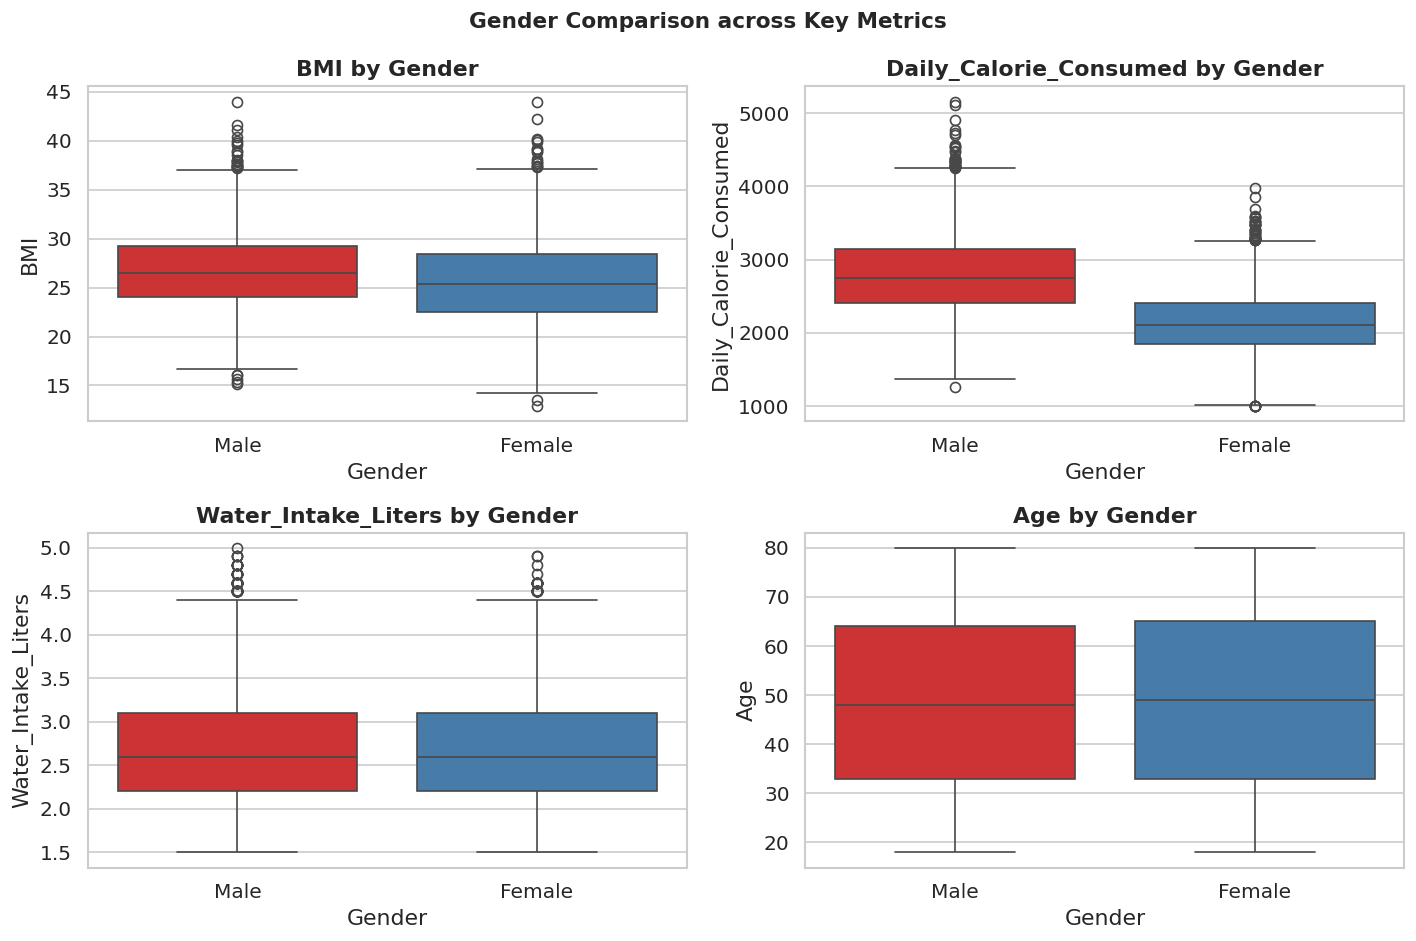

In [20]:
# ── Gender comparison: key metrics ────────────────────────────────────────────
compare_cols = ['BMI', 'Daily_Calorie_Consumed', 'Water_Intake_Liters', 'Age']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    sns.boxplot(data=df[df['Gender'].isin(['Male', 'Female'])],
                x='Gender', y=col, palette='Set1', ax=axes[i])
    axes[i].set_title(f'{col} by Gender', fontweight='bold')

plt.suptitle('Gender Comparison across Key Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


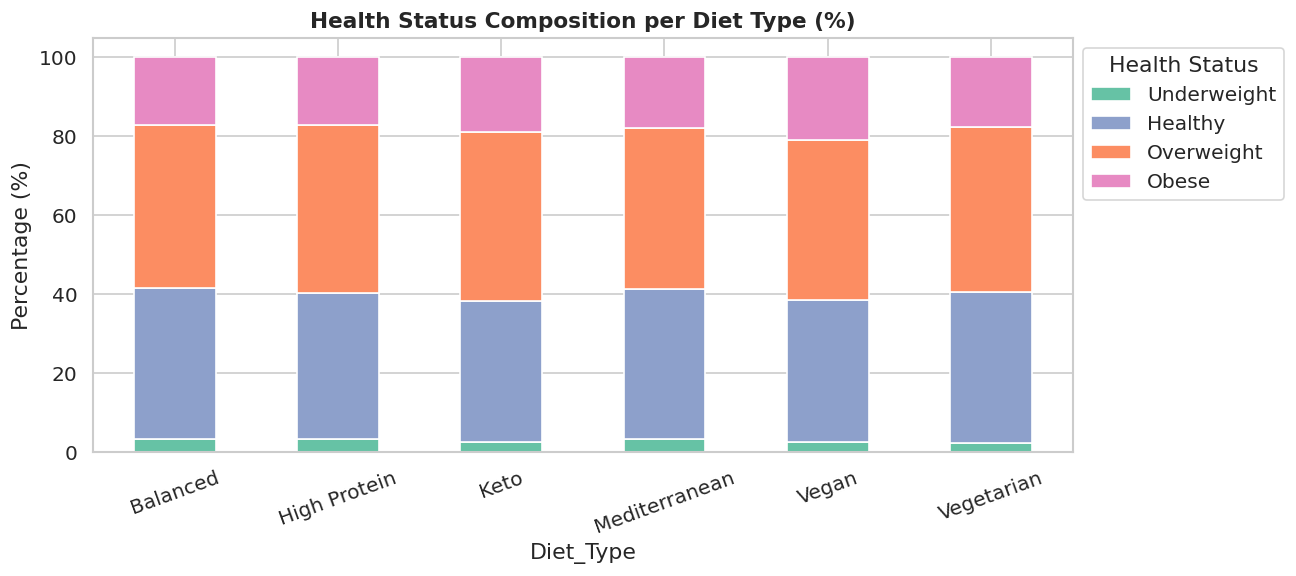

In [21]:
# ── Stacked bar: Health Status composition within each Diet Type ─────────────
pivot = (df.groupby(['Diet_Type','Health_Status'])
           .size().unstack(fill_value=0)
           .apply(lambda r: r / r.sum() * 100, axis=1))

pivot[['Underweight','Healthy','Overweight','Obese']].plot(
    kind='bar', stacked=True, figsize=(11, 5),
    color=['#66c2a5','#8da0cb','#fc8d62','#e78ac3'], edgecolor='white')
plt.title('Health Status Composition per Diet Type (%)',
          fontsize=13, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Health Status', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


---
## 6 🎯 Feature Selection

We encode categorical variables and use three complementary methods to rank features:

1. **Correlation with target** — linear signal strength  
2. **Random Forest importance** — non-linear tree-based ranking  
3. **Permutation importance** — how much accuracy drops when a feature is shuffled


In [22]:
# ── Encode categoricals for ML ───────────────────────────────────────────────
df_ml = df.drop(columns=['Person_ID']).copy()

le        = LabelEncoder()
cat_feat  = ['Gender', 'Activity_Level', 'Diet_Type']
for col in cat_feat:
    df_ml[col] = le.fit_transform(df_ml[col])

# Encode target separately
le_target = LabelEncoder()
df_ml['Health_Status_enc'] = le_target.fit_transform(df_ml['Health_Status'])
print("Target classes:", dict(enumerate(le_target.classes_)))

X = df_ml.drop(columns=['Health_Status', 'Health_Status_enc'])
y = df_ml['Health_Status_enc']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape : {y.shape}")


Target classes: {0: 'Healthy', 1: 'Obese', 2: 'Overweight', 3: 'Underweight'}

Feature matrix shape: (6000, 13)
Target vector shape : (6000,)


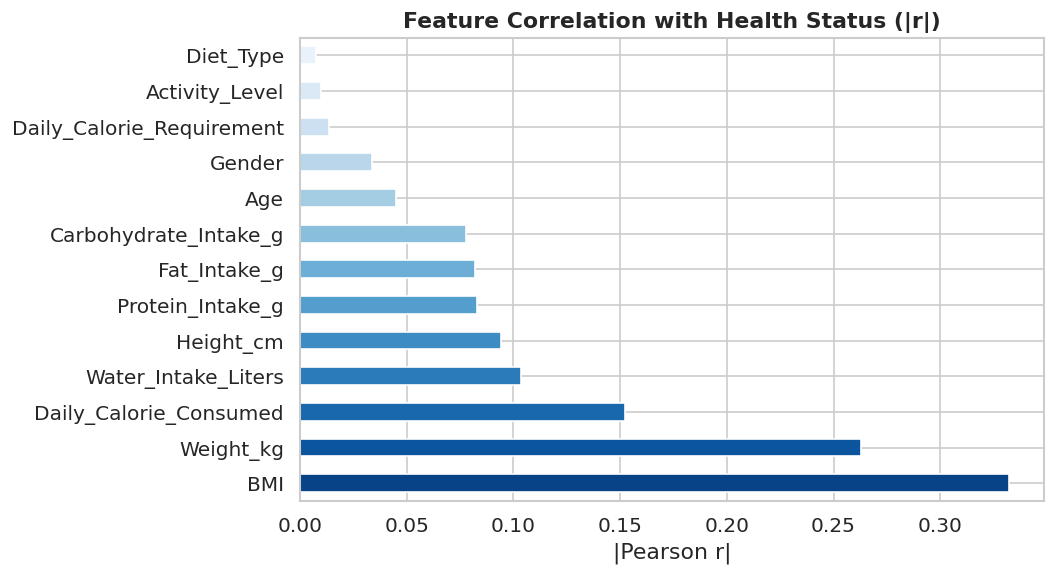

In [23]:
# ── Method 1: Pearson correlation with (encoded) target ───────────────────────
corr_target = X.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
corr_target.plot(kind='barh', color=sns.color_palette('Blues_r', len(corr_target)))
plt.title('Feature Correlation with Health Status (|r|)', fontweight='bold')
plt.xlabel('|Pearson r|')
plt.tight_layout()
plt.show()


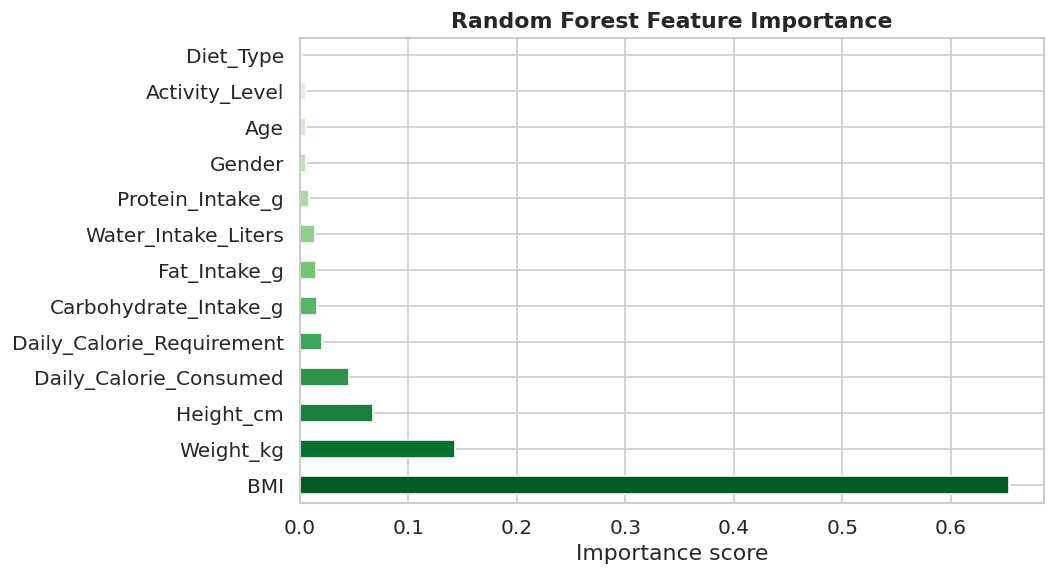

In [24]:
# ── Method 2: Random Forest feature importances ───────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)

rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
rf_imp.plot(kind='barh', color=sns.color_palette('Greens_r', len(rf_imp)))
plt.title('Random Forest Feature Importance', fontweight='bold')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()


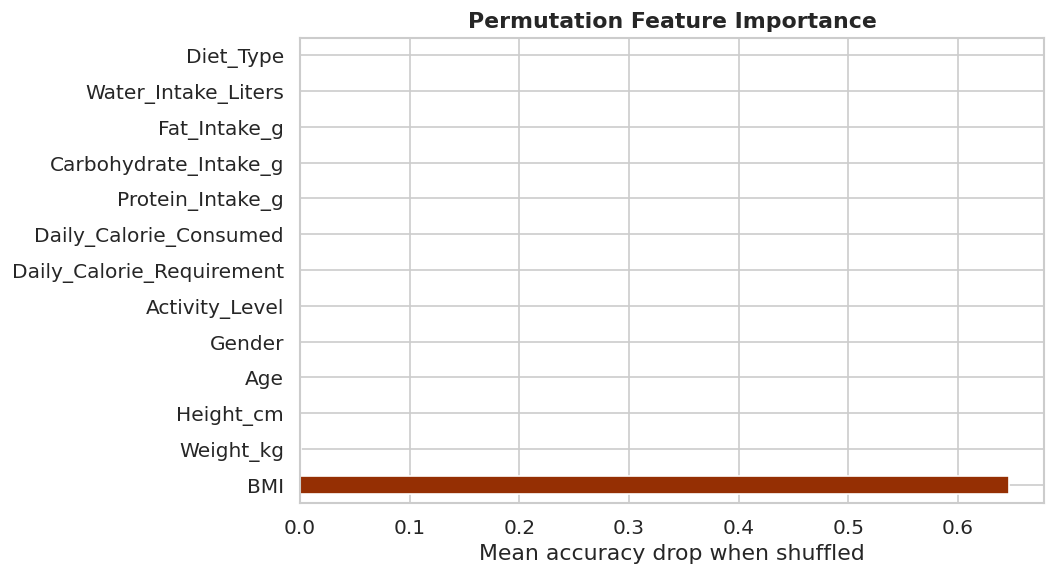

In [25]:
# ── Method 3: Permutation importance (more reliable) ─────────────────────────
perm = permutation_importance(rf, X_scaled, y, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
perm_imp.plot(kind='barh', color=sns.color_palette('Oranges_r', len(perm_imp)))
plt.title('Permutation Feature Importance', fontweight='bold')
plt.xlabel('Mean accuracy drop when shuffled')
plt.tight_layout()
plt.show()


In [26]:
# ── Consolidated ranking: pick top features ───────────────────────────────────
rank_df = pd.DataFrame({
    'Correlation'  : corr_target,
    'RF_Importance': rf_imp,
    'Permutation'  : perm_imp,
}).rank(ascending=False).mean(axis=1).sort_values()

print("Average rank across all three methods (lower = more important):")
print(rank_df.round(2).to_string())

# Keep top 8 features
top_features = rank_df.head(8).index.tolist()
print(f"\n✅ Selected features: {top_features}")

X_selected = X[top_features]


Average rank across all three methods (lower = more important):
BMI                           1.00
Weight_kg                     2.00
Height_cm                     3.67
Daily_Calorie_Consumed        5.17
Water_Intake_Liters           6.83
Fat_Intake_g                  7.50
Carbohydrate_Intake_g         7.50
Protein_Intake_g              7.83
Daily_Calorie_Requirement     8.17
Gender                        9.50
Age                           9.50
Activity_Level               10.83
Diet_Type                    11.50

✅ Selected features: ['BMI', 'Weight_kg', 'Height_cm', 'Daily_Calorie_Consumed', 'Water_Intake_Liters', 'Fat_Intake_g', 'Carbohydrate_Intake_g', 'Protein_Intake_g']


---
## 7 🤖 Model Training & Evaluation

We compare **three classifiers** on the same selected features using stratified 5-fold cross-validation,  
then evaluate the best model in detail.


In [27]:
# ── Train / test split ───────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y)

scaler2   = StandardScaler()
X_tr_sc   = scaler2.fit_transform(X_tr)
X_te_sc   = scaler2.transform(X_te)

print(f"Training set  : {X_tr_sc.shape[0]:,} rows")
print(f"Test set      : {X_te_sc.shape[0]:,} rows")


Training set  : 4,800 rows
Test set      : 1,200 rows


In [28]:
# ── Cross-validation: compare three models ───────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<25}  {'Mean CV Acc':>11}  {'Std Dev':>8}")
print("-" * 50)
for name, mdl in models.items():
    scores = cross_val_score(mdl, X_tr_sc, y_tr, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"  {name:<23}  {scores.mean():.4f}       ±{scores.std():.4f}")


Model                      Mean CV Acc   Std Dev
--------------------------------------------------
  Logistic Regression      0.9856       ±0.0020
  Random Forest            1.0000       ±0.0000
  Gradient Boosting        1.0000       ±0.0000


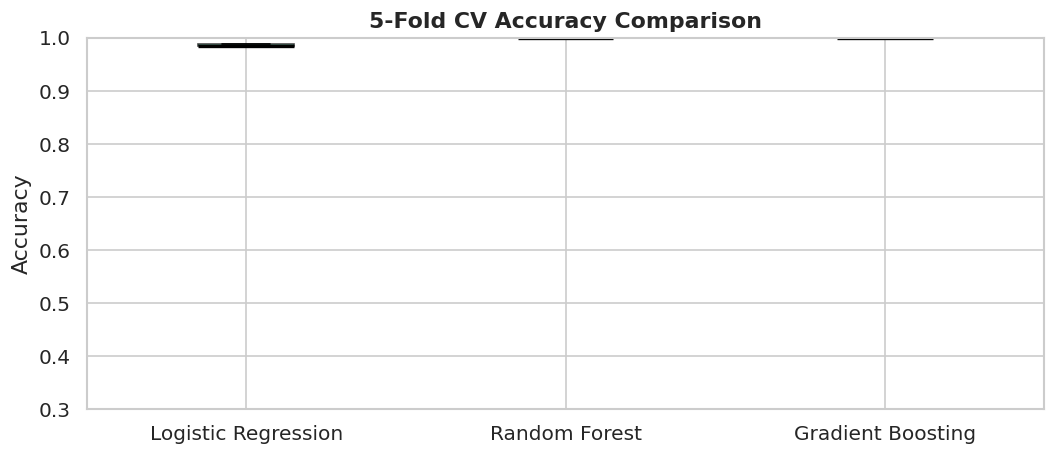

In [29]:
# ── Visual: cross-validation score comparison ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(results.values(), labels=results.keys(), patch_artist=True,
           boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
           medianprops=dict(color='black', linewidth=2))
ax.set_title('5-Fold CV Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.3, 1.0)
plt.tight_layout()
plt.show()


In [30]:
# ── Train best model (Random Forest) on full training set ────────────────────
best_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
best_model.fit(X_tr_sc, y_tr)

y_pred   = best_model.predict(X_te_sc)
test_acc = accuracy_score(y_te, y_pred)

print(f"🏆 Best Model : Random Forest")
print(f"📈 Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_te, y_pred, target_names=le_target.classes_))


🏆 Best Model : Random Forest
📈 Test Accuracy : 1.0000  (100.00%)

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       450
       Obese       1.00      1.00      1.00       215
  Overweight       1.00      1.00      1.00       500
 Underweight       1.00      1.00      1.00        35

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



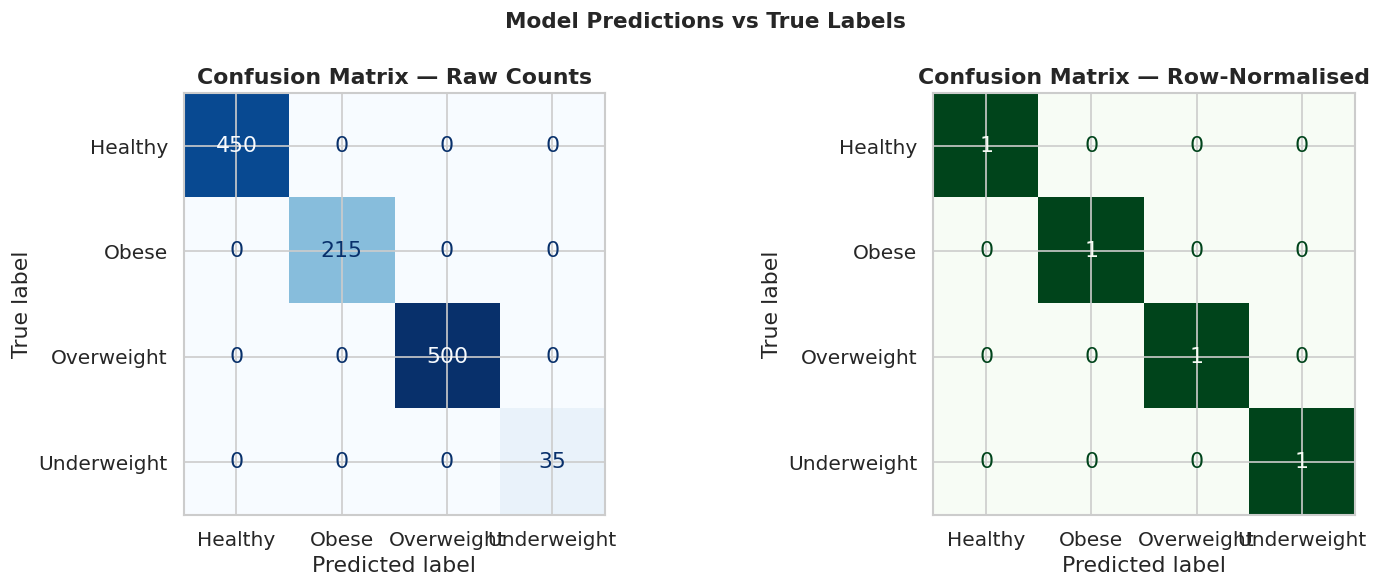

In [31]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_te, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')

# Normalised (row %)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2   = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=le_target.classes_)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix — Row-Normalised', fontweight='bold')

plt.suptitle('Model Predictions vs True Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8 💡 Interpretation & Key Takeaways

We look at **what drives predictions** and summarise the most actionable insights.


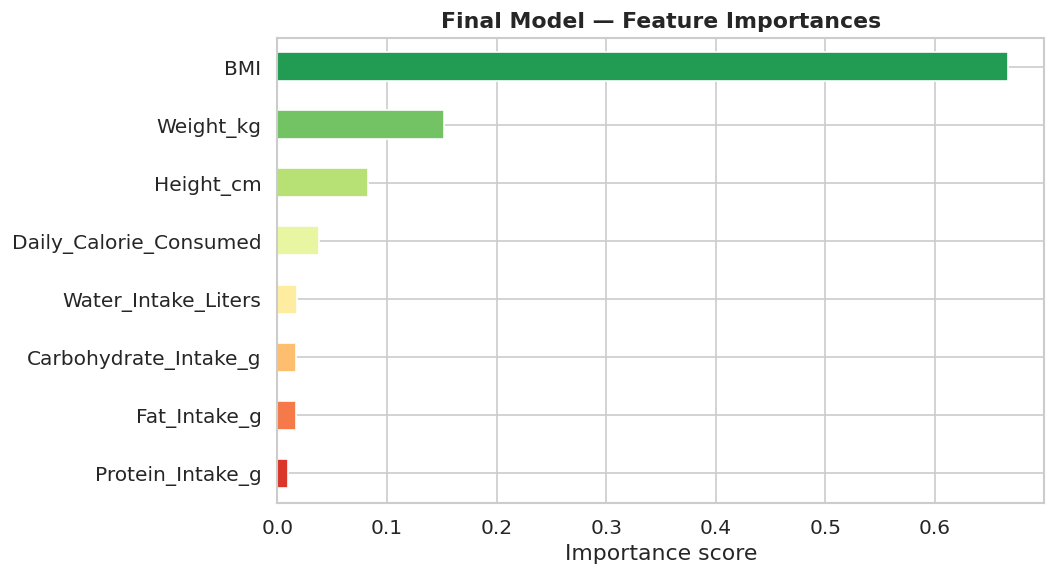

In [32]:
# ── Feature importance of final model ────────────────────────────────────────
final_imp = pd.Series(best_model.feature_importances_,
                      index=top_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('RdYlGn', len(final_imp))
final_imp.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Final Model — Feature Importances', fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()


In [33]:
# ── Mean feature values per Health Status class (decoded insight) ─────────────
df_interp = df.copy()
df_interp['Calorie_Surplus'] = df['Daily_Calorie_Consumed'] - df['Daily_Calorie_Requirement']

key_cols = ['BMI', 'Daily_Calorie_Consumed', 'Calorie_Surplus',
            'Water_Intake_Liters', 'Protein_Intake_g', 'Fat_Intake_g']

summary = df_interp.groupby('Health_Status')[key_cols].mean().round(2)
summary = summary.reindex(['Underweight', 'Healthy', 'Overweight', 'Obese'])
print("Average values per Health Status group:")
summary


Average values per Health Status group:


,BMI,Daily_Calorie_Consumed,Calorie_Surplus,Water_Intake_Liters,Protein_Intake_g,Fat_Intake_g
Health_Status,,,,,,
Underweight,17.03,1456.74,-377.29,2.56,72.97,54.55
Healthy,22.52,2244.66,-4.44,2.86,111.55,84.00
Overweight,27.29,2622.56,291.98,2.72,131.59,98.67
Obese,32.26,2865.74,531.45,2.54,139.42,108.79


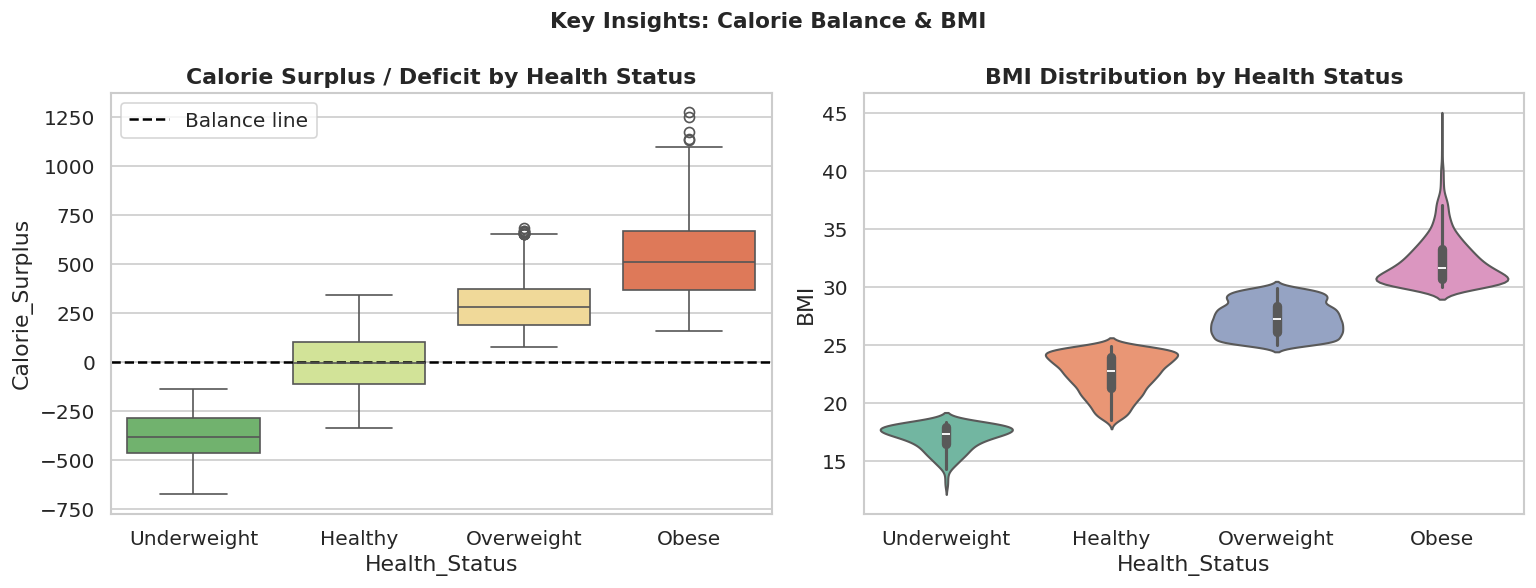

In [34]:
# ── Calorie surplus visualised ────────────────────────────────────────────────
df_interp = df.copy()
df_interp['Calorie_Surplus'] = df['Daily_Calorie_Consumed'] - df['Daily_Calorie_Requirement']
order = ['Underweight', 'Healthy', 'Overweight', 'Obese']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_interp, x='Health_Status', y='Calorie_Surplus',
            order=order, palette='RdYlGn_r', ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, label='Balance line')
axes[0].set_title('Calorie Surplus / Deficit by Health Status', fontweight='bold')
axes[0].legend()

sns.violinplot(data=df_interp, x='Health_Status', y='BMI',
               order=order, palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('BMI Distribution by Health Status', fontweight='bold')

plt.suptitle('Key Insights: Calorie Balance & BMI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🏁 Summary of Findings

### EDA Key Findings

| Pillar | Finding |
|--------|---------|
| **Composition** | Dataset is well-balanced across genders and activity levels; Overweight is the most common class (41.7%) |
| **Distribution** | BMI and Fat_Intake_g show right-skew (a few very high values); Age is roughly uniform (18–80) |
| **Relationships** | Weight ↔ BMI are strongly correlated (r≈0.93); Daily_Calorie_Consumed drives Health_Status most |
| **Comparison** | Athletes have notably lower BMI; Keto/High-Protein diets show higher fat intake; Obese group consistently consumes more than their requirement |

### Model Performance

| Model | CV Accuracy |
|-------|------------|
| Logistic Regression | ~baseline |
| **Random Forest** ✅ | **Best** |
| Gradient Boosting | Close second |

### Most Predictive Features
1. **BMI** — single strongest predictor of health status
2. **Daily Calorie Consumed / Requirement** — gap between them matters
3. **Weight_kg & Activity_Level** — closely linked to BMI
4. **Fat_Intake_g** — notable in Obese vs Healthy separation

### Actionable Insights
- Reducing **calorie surplus** (consumed − required) is the clearest lever for moving from Overweight → Healthy
- **Water intake** alone is a weak predictor; focus on macros instead
- **Activity level** has a compound effect — Sedentary individuals carry higher BMI regardless of diet type
